# Laboratorio 9: Datos Sintéticos

- ¿Porque una empresa podría no compartir sus datos reales?
- ¿Qué sesgos existen al utilizar información personal de clientes?
- ¿Crees que es posible entrenar un modelo de ML sin utilizar datos reales?

In [1]:
#Importamos librerias
from faker import Faker
import pandas as pd
import random

In [2]:
#Creamos una instancia de faker
fake = Faker("es_MX")

In [3]:
#generamos datos sintaticos:100 registros
datos = []
for i in range(1000):
    datos.append({
        "id_usuario": i + 1,
        "nombre": fake.name(),
        "correo": fake.email(),
        "edad": random.randint(18,65),
        "seguidores": random.randint(100, 50000),
        "plataforma": random.choice(
        ["TikTok", "Instagram", "Youtube"]
    )
})

In [4]:
df = pd.DataFrame(datos)
df.head()

,id_usuario,nombre,correo,edad,seguidores,plataforma
0,1,Soledad Frida Abreu Barela,zroque@example.net,38,32213,Instagram
1,2,Ramiro Negrón Treviño,abrahamlugo@example.net,18,26375,Instagram
2,3,Timoteo Alejandro Benavídez,vcarranza@example.com,53,463,TikTok
3,4,Bruno Eric Gaitán,gilbertogalindo@example.com,19,17374,Youtube
4,5,David Carreón,vvalladares@example.com,51,4926,Instagram


In [5]:
#Exploracion del Dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id_usuario  1000 non-null   int64 
 1   nombre      1000 non-null   object
 2   correo      1000 non-null   object
 3   edad        1000 non-null   int64 
 4   seguidores  1000 non-null   int64 
 5   plataforma  1000 non-null   object
dtypes: int64(3), object(3)
memory usage: 47.0+ KB


In [6]:
#Estadistica descriptiva
df.describe(include="all")

,id_usuario,nombre,correo,edad,seguidores,plataforma
count,1000.000000,1000,1000,1000.000000,1000.000000,1000
unique,NaN,1000,999,NaN,NaN,3
top,NaN,Soledad Frida Abreu Barela,cvaldivia@example.net,NaN,NaN,Instagram
freq,NaN,1,2,NaN,NaN,351
mean,500.500000,NaN,NaN,41.509000,24724.043000,NaN
std,288.819436,NaN,NaN,13.915371,14672.735411,NaN
min,1.000000,NaN,NaN,18.000000,162.000000,NaN
25%,250.750000,NaN,NaN,29.000000,11839.750000,NaN
50%,500.500000,NaN,NaN,42.000000,24352.500000,NaN
75%,750.250000,NaN,NaN,53.000000,37285.000000,NaN


In [7]:
#importar librerias para graficar
import seaborn as sns
import matplotlib.pyplot as plt

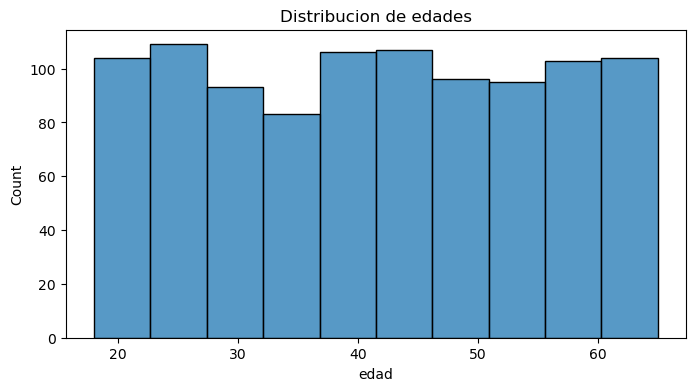

In [8]:
#Distribucion de edades
plt.figure(figsize=(8,4))
sns.histplot(
    df["edad"],
    bins=10
)
plt.title("Distribucion de edades")
plt.show()

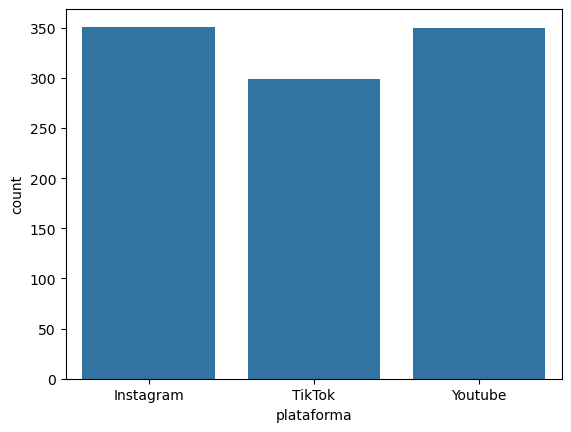

In [9]:
sns.countplot(
    x="plataforma",
    data=df
)
plt.show()

In [10]:
#Generamos una copia para contaminarla
df_sucio = df.copy()

In [11]:
#Le colocamos valores nulos
for i in random.sample(range(len(df_sucio)),5):
    df_sucio.loc[i,"nombre"] = None

In [12]:
df_sucio.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id_usuario  1000 non-null   int64 
 1   nombre      995 non-null    object
 2   correo      1000 non-null   object
 3   edad        1000 non-null   int64 
 4   seguidores  1000 non-null   int64 
 5   plataforma  1000 non-null   object
dtypes: int64(3), object(3)
memory usage: 47.0+ KB


In [13]:
#edades inválidas
for i in random.sample(range(len(df_sucio)),5):
    df_sucio.loc[i, "edad"] = -10

In [14]:
df_sucio.describe()["edad"]

count    1000.000000
mean       41.274000
std        14.340941
min       -10.000000
25%        29.000000
50%        42.000000
75%        53.000000
max        65.000000
Name: edad, dtype: float64

In [15]:
#Seguidores imposibles
for i in random.sample(range(len(df_sucio)), 5):
    df_sucio.loc[i,"seguidores"]= 5000000

In [16]:
df_sucio.describe()["seguidores"]

count    1.000000e+03
mean     4.958042e+04
std      3.514060e+05
min      1.620000e+02
25%      1.185850e+04
50%      2.441100e+04
75%      3.763700e+04
max      5.000000e+06
Name: seguidores, dtype: float64

In [17]:
#Generamos correos invalidos
for i in random.sample(range(len(df_sucio)), 5):
    df_sucio.loc[i,"correo"]= "correo_invalido"

In [18]:
df_sucio.describe(include=["string","object"])

,nombre,correo,plataforma
count,995,1000,1000
unique,995,995,3
top,Soledad Frida Abreu Barela,correo_invalido,Instagram
freq,1,5,351


In [19]:
df_sucio.isnull().sum()

id_usuario    0
nombre        5
correo        0
edad          0
seguidores    0
plataforma    0
dtype: int64

In [20]:
pd.set_option('display.float_format',lambda x: '%.2f' % x)

In [21]:
df_sucio.describe(include="all")

,id_usuario,nombre,correo,edad,seguidores,plataforma
count,1000.00,995,1000,1000.00,1000.00,1000
unique,NaN,995,995,NaN,NaN,3
top,NaN,Soledad Frida Abreu Barela,correo_invalido,NaN,NaN,Instagram
freq,NaN,1,5,NaN,NaN,351
mean,500.50,NaN,NaN,41.27,49580.42,NaN
std,288.82,NaN,NaN,14.34,351405.99,NaN
min,1.00,NaN,NaN,-10.00,162.00,NaN
25%,250.75,NaN,NaN,29.00,11858.50,NaN
50%,500.50,NaN,NaN,42.00,24411.00,NaN
75%,750.25,NaN,NaN,53.00,37637.00,NaN
